In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # at least for heatmap
import re


relativepath = 'C:\\Users\\Veronika\\DATABASES\\EnergyConsumption\\'

In [2]:
print(pd.__version__)
print(sns.__version__)

1.2.4
0.11.1


In [3]:
# import matplotlib
# matplotlib.__version__ # 3.1.3
# note: with "import matplotlib.pyplot as plt" I can't check version - neither of plt, nor matplotlib

In [4]:
pd.set_option('display.max_columns', 70)

drop next blocks until "Questions" when I create modelisation notebook separately

In [5]:
import scipy.stats as stats

In [6]:
import statsmodels.api as sm
from scipy.stats import norm
import pylab

# Load the database

In [7]:
data_2015 = pd.read_csv(relativepath + '2015_building_energy_benchmarking.csv')

In [8]:
data_2015.shape

(3340, 47)

In [9]:
data_2015.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'TaxParcelIdentificationNumber', 'Location',
       'CouncilDistrictCode', 'Neighborhood', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'OtherFuelUse(kBtu)',
       'GHGEmissions(MetricTonsCO2e)', 'GHGEmissionsIntensity(kgCO2e/ft2)',
       'DefaultData', '

In [10]:
data_2015.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3340 entries, 0 to 3339
Data columns (total 47 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   OSEBuildingID                                                  3340 non-null   int64  
 1   DataYear                                                       3340 non-null   int64  
 2   BuildingType                                                   3340 non-null   object 
 3   PrimaryPropertyType                                            3340 non-null   object 
 4   PropertyName                                                   3340 non-null   object 
 5   TaxParcelIdentificationNumber                                  3338 non-null   object 
 6   Location                                                       3340 non-null   object 
 7   CouncilDistrictCode                                         

In [11]:
data_2015.describe()

,OSEBuildingID,DataYear,CouncilDistrictCode,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),OtherFuelUse(kBtu),GHGEmissions(MetricTonsCO2e),GHGEmissionsIntensity(kgCO2e/ft2),2010 Census Tracts,Seattle Police Department Micro Community Policing Plan Areas,City Council Districts,SPD Beats,Zip Codes
count,3340.000000,3340.0,3340.000000,3340.000000,3340.000000,3332.000000,3.340000e+03,3340.000000,3.340000e+03,3.204000e+03,1559.000000,560.000000,2560.000000,3330.000000,3330.000000,3330.000000,3330.000000,3.330000e+03,3.330000e+03,3.330000e+03,3.330000e+03,3.330000e+03,3.330000e+03,3.330000e+03,3.330000e+03,3330.000000,3330.000000,224.000000,3338.000000,213.000000,3338.000000,3340.000000
mean,20522.168263,2015.0,4.450898,1967.624850,1.035629,4.682173,9.077289e+04,11054.032335,7.971886e+04,7.488154e+04,27675.646568,10755.708929,67.894141,53.626126,57.586547,132.779730,138.936036,4.983106e+06,5.203055e+06,2.502851e+05,1.017897e+06,3.473209e+06,1.253304e+04,1.253304e+06,7.142301e+03,110.094102,0.985339,123.062500,32.380168,1.347418,24.825644,18786.680240
std,11511.515874,0.0,2.127203,32.949847,0.784463,5.458460,1.493058e+05,35296.330507,1.292314e+05,1.236249e+05,52480.843425,22618.529737,27.154057,53.893311,55.604963,131.943223,131.359121,1.375330e+07,1.400757e+07,3.481900e+06,2.789931e+06,9.519639e+06,4.415142e+04,4.415142e+06,1.962790e+05,409.450179,1.637172,5.812128,19.907567,0.477272,15.006287,588.604192
min,1.000000,2015.0,1.000000,1900.000000,1.000000,0.000000,2.000000e+04,-3.000000,-5.055000e+04,5.872000e+03,0.000000,0.000000,1.000000,0.000000,0.000000,-2.000000,-2.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,116.000000,1.000000,1.000000,1.000000,17916.000000
25%,19921.750000,2015.0,3.000000,1947.000000,1.000000,2.000000,2.848700e+04,0.000000,2.668300e+04,2.500000e+04,4959.000000,2385.250000,51.750000,27.300000,29.700000,73.500000,80.300000,9.139300e+05,9.883248e+05,0.000000e+00,1.864908e+05,6.363322e+05,0.000000e+00,0.000000e+00,0.000000e+00,9.265000,0.080000,117.000000,14.000000,1.000000,10.000000,18379.000000
50%,22977.000000,2015.0,4.000000,1973.000000,1.000000,4.000000,4.385500e+04,0.000000,4.132600e+04,3.900000e+04,10600.000000,5019.500000,76.000000,37.400000,40.900000,95.000000,102.800000,1.776219e+06,1.953996e+06,0.000000e+00,3.400320e+05,1.160236e+06,2.945500e+03,2.945770e+05,0.000000e+00,32.740000,0.460000,123.000000,33.000000,1.000000,26.000000,18390.000000
75%,25748.000000,2015.0,7.000000,1996.000000,1.000000,5.000000,8.842800e+04,4304.250000,7.872600e+04,7.206750e+04,26224.500000,10275.000000,90.000000,59.875000,65.575000,143.900000,151.275000,4.044277e+06,4.368462e+06,0.000000e+00,8.061935e+05,2.750847e+06,1.115325e+04,1.115366e+06,0.000000e+00,88.642500,1.180000,125.500000,50.000000,2.000000,38.000000,19576.000000
max,50059.000000,2015.0,7.000000,2015.000000,39.000000,99.000000,2.200000e+06,512608.000000,2.200000e+06,1.719643e+06,686750.000000,303910.000000,100.000000,800.600000,800.600000,2511.100000,2511.000000,2.958126e+08,2.977410e+08,1.278697e+08,8.344505e+07,2.847263e+08,1.364484e+06,1.364484e+08,8.269669e+06,11824.890000,31.380000,135.000000,61.000000,2.000000,51.000000,19584.000000


In [3]:
data_2016 = pd.read_csv(relativepath + '2016_building_energy_benchmarking.csv')

In [13]:
data_2016.shape

(3376, 46)

In [14]:
data_2016.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'City', 'State', 'ZipCode',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus',
       'Outlier

In [15]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

In [16]:
data_2016.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,3376.000000,3.376000e+03,3.356000e+03,1679.000000,596.000000,2533.000000,3369.000000,3370.000000,3367.000000,3367.000000,3.371000e+03,3.370000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,0.0,3367.000000,3367.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,8001.526066,8.683201e+04,7.917764e+04,28444.075817,11738.675166,67.918674,54.732116,57.033798,134.232848,137.783932,5.403667e+06,5.276726e+06,2.745959e+05,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,119.723971,1.175916
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,32326.723928,2.079398e+05,2.017034e+05,54392.917928,29331.199286,26.873271,56.273124,57.163330,139.287554,139.109807,2.161063e+07,1.593879e+07,3.912173e+06,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,538.832227,1.821452
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-2.100000,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,0.000000,2.775600e+04,2.509475e+04,5000.000000,2239.000000,53.000000,27.900000,29.400000,74.699997,78.400002,9.251286e+05,9.701822e+05,0.000000e+00,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,9.495000,0.210000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,0.000000,4.321600e+04,3.989400e+04,10664.000000,5043.000000,75.000000,38.599998,40.900002,96.199997,101.099998,1.803753e+06,1.904452e+06,0.000000e+00,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,33.920000,0.610000
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,0.000000,8.427625e+04,7.620025e+04,26640.000000,10138.750000,90.000000,60.400002,64.275002,143.899994,148.349998,4.222455e+06,4.381429e+06,0.000000e+00,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,93.940000,1.370000
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,686750.000000,459748.000000,100.000000,834.400024,834.400024,2620.000000,2620.000000,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000,34.090000


I can't use the following columns as features, only as targets:

'SiteEUI(kBtu/sf)',       'SiteEUIWN(kBtu/sf)', 
'SourceEUI(kBtu/sf)', 	'SourceEUIWN(kBtu/sf)',
'SiteEnergyUse(kBtu)',	 'SiteEnergyUseWN(kBtu)', 
'SteamUse(kBtu)',
'Electricity(kWh)',	 'Electricity(kBtu)', 
'NaturalGas(therms)',		'NaturalGas(kBtu)',
'TotalGHGEmissions', 	'GHGEmissionsIntensity',

'GHGEmissions(MetricTonsCO2e)',		 'GHGEmissionsIntensity(kgCO2e/ft2)',
'OtherFuelUse(kBtu)'.

It's because it was formulated in the project description that I should avoid using these metrics as features in prediction.

In [17]:
set_2016 = set(data_2016.columns)
set_2015 = set(data_2015.columns)

In [18]:
set_2015 - set_2016

{'2010 Census Tracts',
 'City Council Districts',
 'Comment',
 'GHGEmissions(MetricTonsCO2e)',
 'GHGEmissionsIntensity(kgCO2e/ft2)',
 'Location',
 'OtherFuelUse(kBtu)',
 'SPD Beats',
 'Seattle Police Department Micro Community Policing Plan Areas',
 'Zip Codes'}

In [19]:
set_2016 - set_2015

{'Address',
 'City',
 'Comments',
 'GHGEmissionsIntensity',
 'Latitude',
 'Longitude',
 'State',
 'TotalGHGEmissions',
 'ZipCode'}

In [20]:
set_2016.intersection(set_2015)

{'BuildingType',
 'ComplianceStatus',
 'CouncilDistrictCode',
 'DataYear',
 'DefaultData',
 'ENERGYSTARScore',
 'Electricity(kBtu)',
 'Electricity(kWh)',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'ListOfAllPropertyUseTypes',
 'NaturalGas(kBtu)',
 'NaturalGas(therms)',
 'Neighborhood',
 'NumberofBuildings',
 'NumberofFloors',
 'OSEBuildingID',
 'Outlier',
 'PrimaryPropertyType',
 'PropertyGFABuilding(s)',
 'PropertyGFAParking',
 'PropertyGFATotal',
 'PropertyName',
 'SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'SiteEUI(kBtu/sf)',
 'SiteEUIWN(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'SourceEUI(kBtu/sf)',
 'SourceEUIWN(kBtu/sf)',
 'SteamUse(kBtu)',
 'TaxParcelIdentificationNumber',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'YearBuilt',
 'YearsENERGYSTARCertified'}

Total GHG Emissions is the same that GHG Emissions in metric tons.
GHGE Emissions Intensity is the same that GHG Emissions Intensity (kg CO2 / square foot)

# Action plan
- make a correlation matrix, display it as a heatmap. Notice which variables are correlated lineraly with target variables.
- make univariate analysis: do distribution analysis (histogram or boxplot), for some of the numeric columns (that I consider as future features, X, for my regressions).
- decision point: if the distributions are similar for both tables, make a concatenation table: but for making a concatenation table I have to process "Location" column in data_2015 first.
- drop null values for target columns: these are WN Site Energy Use and Total GHG emissions. If I don't have target values, I still can use them  for test, but it will be a blind test - I will never be able to evaluate how well the test has succeeded.
- See where I still have NaN values: see what I can fill with mode (number of buildings, number of floors - because they have exponential distribution, so it's a bad idea to fill them with median or mean), which columns I can drop as not relevant instead of wasting time on filling them. Which lines I can drop, if filling the NaN risk to introduce an error.
- Look at the outliers. Think if I want to drop the outliers. I will calculate outliers by standard method: Q1 - 1.5 IQR, Q3 + 1.5 IQR. Or, maybe in some cases I will have to apply extended range: 3 IQR, not 1.5 IQR.
- About EnergyStarScore: maybe it's the best to make a copy of the dataset and fit the EnergyStar in a copy. And check if after filling the EnergyStar Score is more correlated with the targets and before filling.

This caution is needed because we are gonna check whether EnergyStar Score is useful or not. If a correlation increases, we risk to evaluate the EnergyStar Score as more useful and valuable than it actually is.

- See if we have rows that describe the same building: by BuildingID; by BuildingID and geographical location only (latitude, longitude) - that doesn't mean the the building has crawled away, but just that the measurement was taken badly. By BuildingID and administrative location: that means change in districts and neighbourhood borders between 2015 and 2016. Between BuildingID and GrossFloorArea and NumberofFloors - that means construction works on these buildings. Between BuildingID and NumberofBuildings: this means change in assignment of buildings to an object, or additional construction or destroyment of a building in a group. 

# Correlations in the data

In [21]:
for_corr = data_2015.drop(['DataYear'], axis=1)

In [22]:
corr_matr = for_corr.corr()
# mask = np.zeros_like(corr_matr)
# mask[np.triu_indices_from(mask)] = True # creates an array with 1111, 0111, 0011, 0001, not 0000

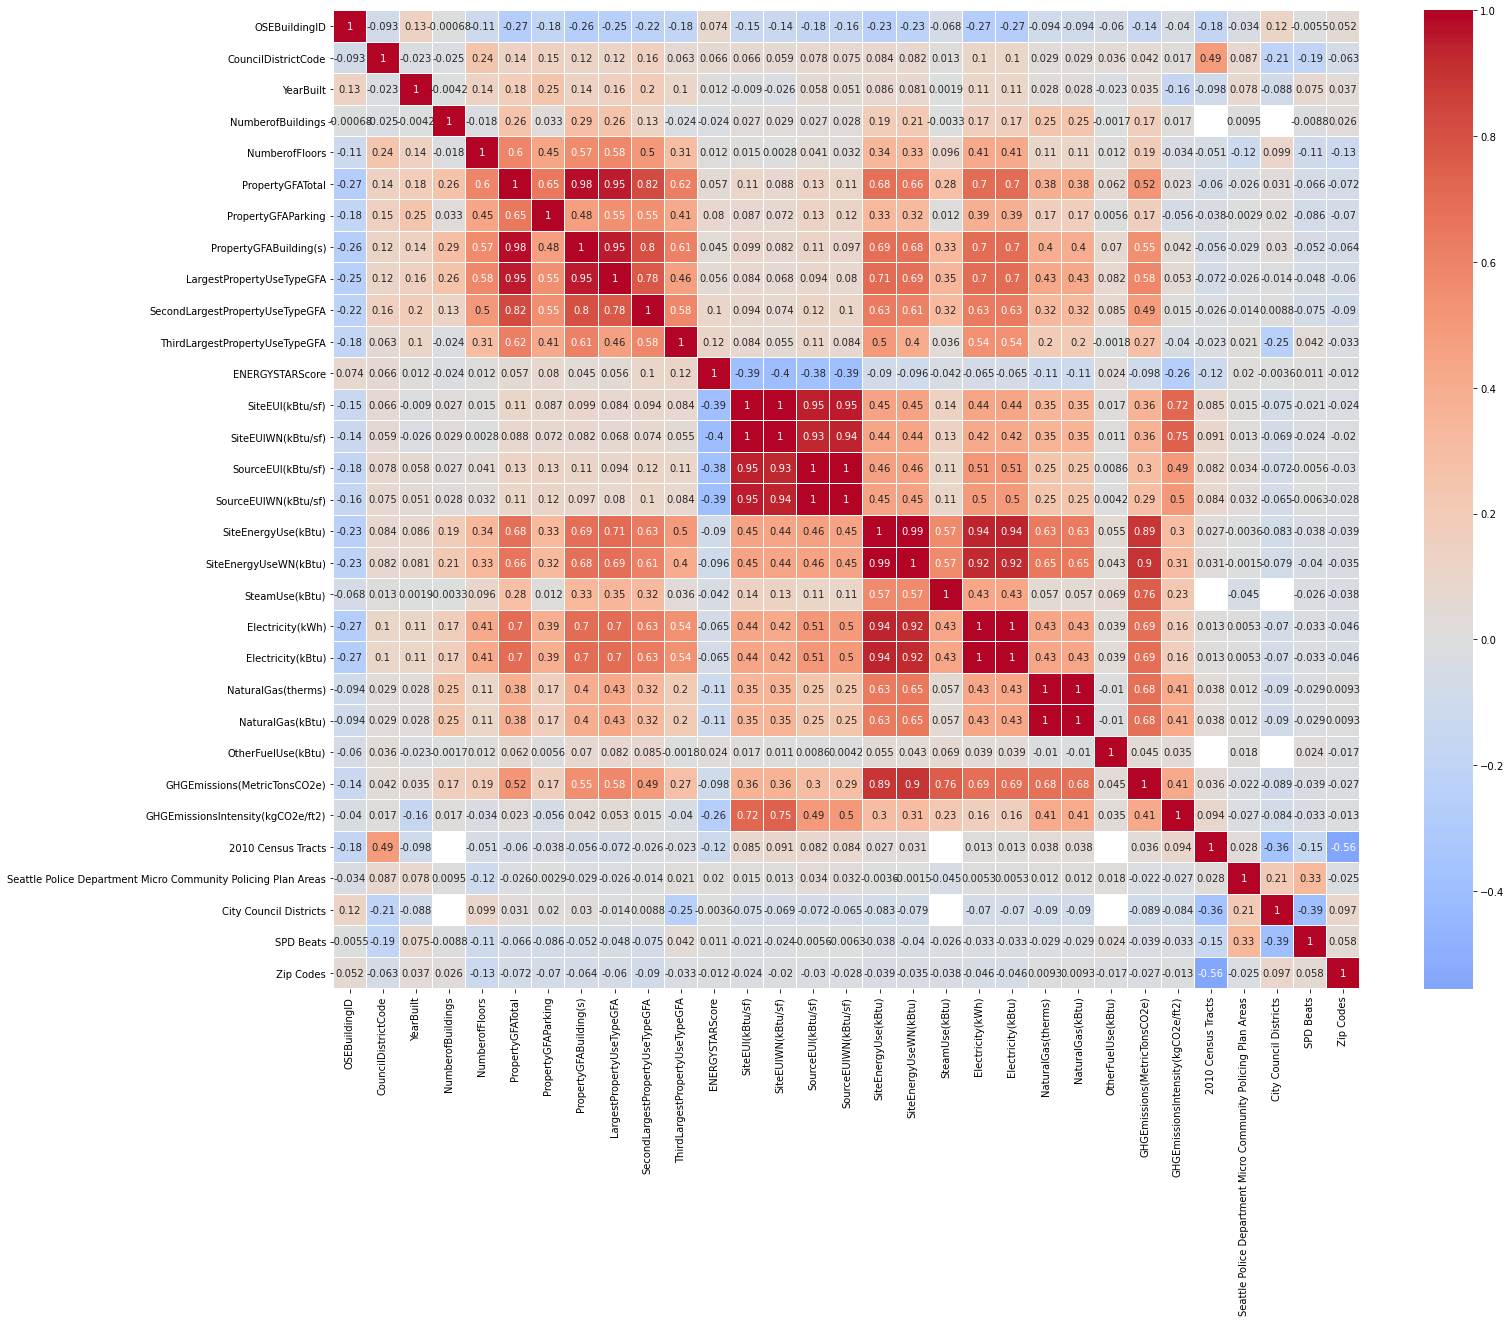

In [23]:
fig = plt.figure(figsize=(23,18))
sns.heatmap(corr_matr, square=False, linewidths=0.01, center=0, annot=True, cmap='coolwarm') # mask=mask, 
# center=0 is a center of the colorscale: to which value the center of the colorscale is assigned
plt.xticks(rotation=90)
# plt.title("Correlations between variables")
plt.show()

Electricity and NaturalGas in different units are fully correlated by all the methods of correlation calculation. I can keep only one of them. For example, leave those in kBtu, in order to have more of the variables in the same units

I see that EnergyStarscore is correlated with energy intensity WN by -0.4, but not with target SiteEnergyUse (by -0.1).
Maybe the correlation will be better with EnergyStarscore proportional to the surface. Shall I try to see the correlation coefficients for (EnergyStarScore * GFA Total) vs SiteEnergyUse? Or just let the linear regression do the job?

In fact, SiteEnergyUse is more correlated with LargestTypeUseGFA, second largest and even third largest more than with EnergyStar Score.

Also SiteEnergyUse and CO2 emissions are highly correlated with SiteEnergyuse (WN and not WN). But emissions are not correlated with EnergyStar Score (by -0.26)

Between Site and Source Energy - it's advised to prefer to keep Source Energy by
https://www.energystar.gov/buildings/benchmark/understand_metrics/source_site_difference.
Between WN energy (WEATHER NORMALIZED) and not WN it's better to use WN, because we have the data only for 2 years, and WN is calculated/estimated for avaraged temperatures in 30 years
https://www.lawinsider.com/dictionary/weather-normalized-site-eui

In [24]:
for_corr = data_2016.drop(['DataYear', 'Comments'], axis=1)

In [25]:
corr_matr = for_corr.corr()
# mask = np.zeros_like(corr_matr)
# mask[np.triu_indices_from(mask)] = True # creates an array with 1111, 0111, 0011, 0001, not 0000

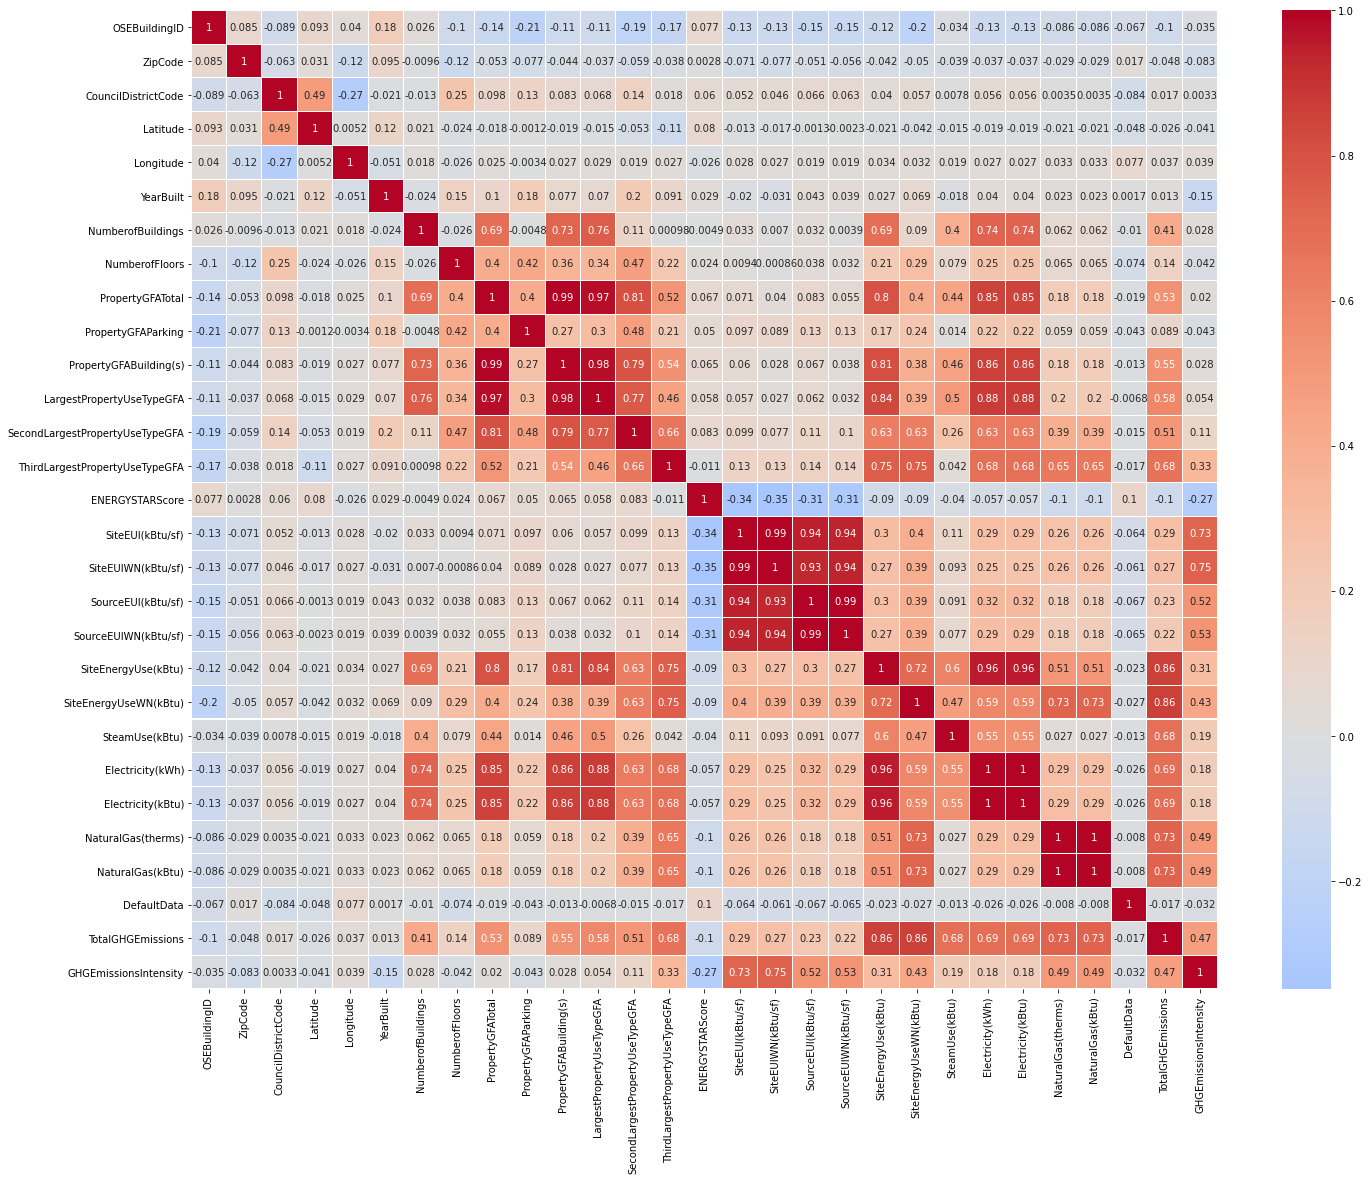

In [26]:
fig = plt.figure(figsize=(23,18))
sns.heatmap(corr_matr, square=False, linewidths=0.01, center=0, annot=True, cmap='coolwarm') # mask=mask, 
# center=0 is a center of the colorscale: to which value the center of the colorscale is assigned
# coolwarm_r for reverse
plt.xticks(rotation=90)
# plt.title("Correlations between variables")
plt.show()

In 2016 EnergyStar Score is correlated slightly better with targets, but Total GFA, Buildings GFA, LargestTypeUse GFA are also more correlated in 2016 than in 2015. Interestingly, correlation coefficient is larger for ThirdLargestUse than for SecondLargestUse.

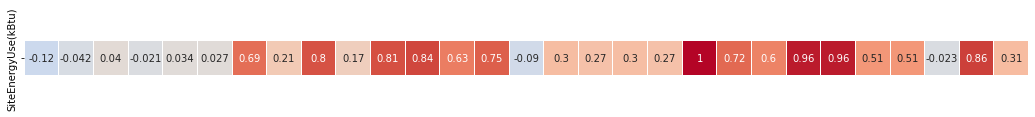

In [27]:
# fig = plt.figure(figsize=(16,12))
fig = plt.figure(figsize=(18,1.8))
# sns.heatmap(corr_matr.iloc[11:22, 11:22], square=False, linewidths=0.01, center=0, annot=True, cmap='coolwarm') # mask=mask, 
sns.heatmap(corr_matr.iloc[-10:-9, :], square=True, linewidths=0.01, center=0, annot=True, fmt='.2g', cmap='coolwarm', cbar=False) 
# plt.xticks(rotation=90)
plt.xticks([])
plt.yticks(rotation=90, va='center')
plt.show()

# Univariate analysis

## Information about categorical columns

Name of a column can be replaced

In [28]:
# data_2015['LargestPropertyUseType'].value_counts()

In [29]:
# data_2015['LargestPropertyUseType'].nunique()

OSEBuildingID can be a key column? No duplicates for data_2015. DataYear has only one value - can be dropped?

BuildingType has 7 values - can it be useful for regression with get dummies?
PrimaryPropertyType has 27 values, after text processing maybe around 20 values.

TaxParcelIdentificationNumber is like an individual number, but with some duplicates - useless regression.
PropertyName - the same.

"Location" is a dictionary with latitude, longitude, and human_address (which is a dictionary with address, city, state, zip) Human adress seems useles for regression: city and state are supposed to be identical for all the entries, address is hard to process because of its non-uniformity, zip codes could be interesting for classification, but they are too numerous.

CouncilDistrictCode has 7 distinct values: from 1 to 7. Can it be useful for regression with get dummies?
Neighborhood has 13 distinct values: Downtown, East etc. Can it be useful for regression with get dummies?

ListOfAllPropertyUseTypes is a list with many rare values, occuring 1 or 2 times. It would be a pain to process it, so for the moment I decide to drop this column.

LargestPropertyUseType has too many variables for be used in regression. Maybe, if the values are regrouped into larger groups.
maybe to make an ANOVA to see the correlation between LargestUse GFA and LargestUse Type, because we know GFA is somewhat correlated with targets. (Or make contingency table to see if there is a correlation between PrimaryPropertyType and LargestPropertyUseType, but this makes less sense, since PrimaryPropertyType isn't correlated with targets). No, we don't know it from a heatmap - we have correlation coefficients only for numeric columns.

YearsENERGYSTARCertified - seems a useless column: to be dropped.

ComplianceStatus: 3337 compliant, 3 not compliant.

In [30]:
data_2015['Zip Codes'].unique()

array([18081, 19576, 18379, 18800, 18383, 18789, 19579, 18390, 18377,
       18235, 18792, 18386, 17919, 19575, 19578, 19581, 19582, 17920,
       18385, 18388, 19584, 18798, 17916, 18795, 17923, 17926, 18229,
       18376, 18230], dtype=int64)

In [31]:
data_2016['ZipCode'].unique()

array([98101., 98121., 98104., 98154., 98118., 98105., 98112., 98125.,
       98109., 98070., 98108., 98199., 98115., 98107., 98144., 98103.,
       98119., 98136., 98122., 98126., 98133., 98146., 98033., 98106.,
       98111., 98134., 98117., 98116., 98191., 98164., 98195., 98185.,
       98181., 98102., 98168., 98155., 98006., 98124., 98053., 98012.,
       98013., 98028., 98178., 98114., 98127., 98165., 98011., 98198.,
       98113., 98040., 98204., 98177., 98020., 98272., 98145.,    nan])

In [32]:
len(data_2015['Zip Codes'].unique())

29

In [33]:
len(data_2016['ZipCode'].unique())

56

I don't see how I can combine zip codes. Google says that modern zip codes are those starting from 98.
one way to fix the Zip Codes of data_2015 is to assign these of 2016, according to BuildingID. But for the moment I will just drop the column.

In [34]:
len(data_2015['Seattle Police Department Micro Community Policing Plan Areas'].unique())

62

In [35]:
len(data_2015['SPD Beats'].unique())

52

I can assign Policy Beats department to 2016 buildings from those of 2015 as well. That would give 62 columns after get_dummies.

SPD beats would give 52 get_dummies columns.

For the moment I will not consider them as useful, and will just drop these columns.

## Distributions in numeric columns

In [36]:
distrib_columns = ['NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseTypeGFA', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(kBtu)',
       'GHGEmissions(MetricTonsCO2e)', 'GHGEmissionsIntensity(kgCO2e/ft2)', 'ENERGYSTARScore', 'YearBuilt']

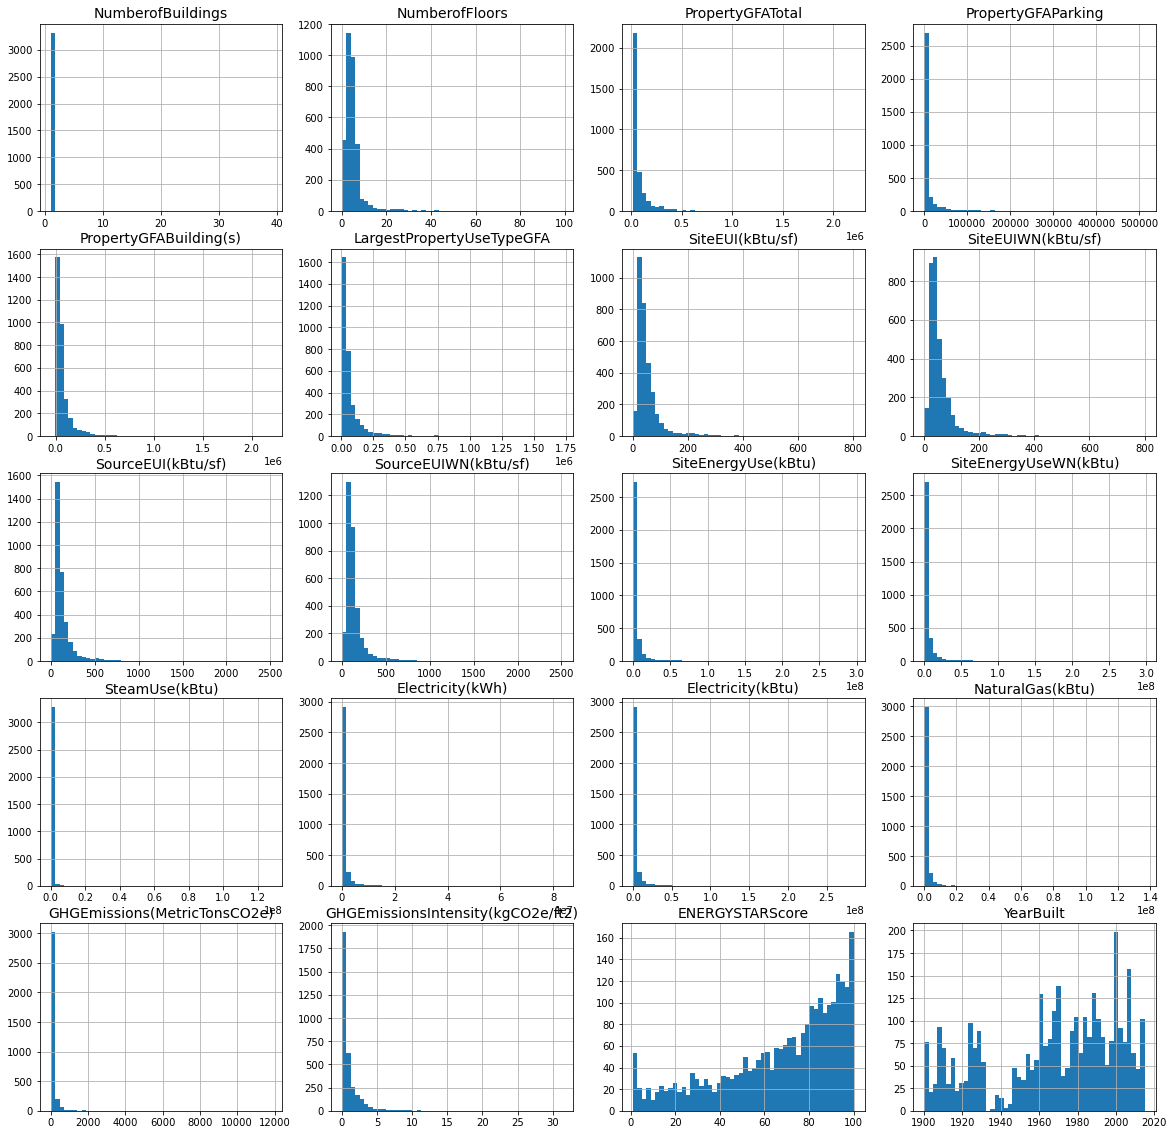

In [37]:
fig = plt.figure(figsize=(20, 20))

for i in range(len(distrib_columns)):
    fig.add_subplot(5,4,i+1)
    ax = data_2015[distrib_columns[i]].hist(bins=50, edgecolor='none')
    ax.set_title(distrib_columns[i], fontsize=14)
    
plt.show()

All the distributions are exponential. All, except EnergyStarScore, are very curved (have high degree of exponent), and year built.

In [38]:
distrib_columns = ['NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseTypeGFA', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 
                   'TotalGHGEmissions', 'GHGEmissionsIntensity', 'ENERGYSTARScore', 'YearBuilt']

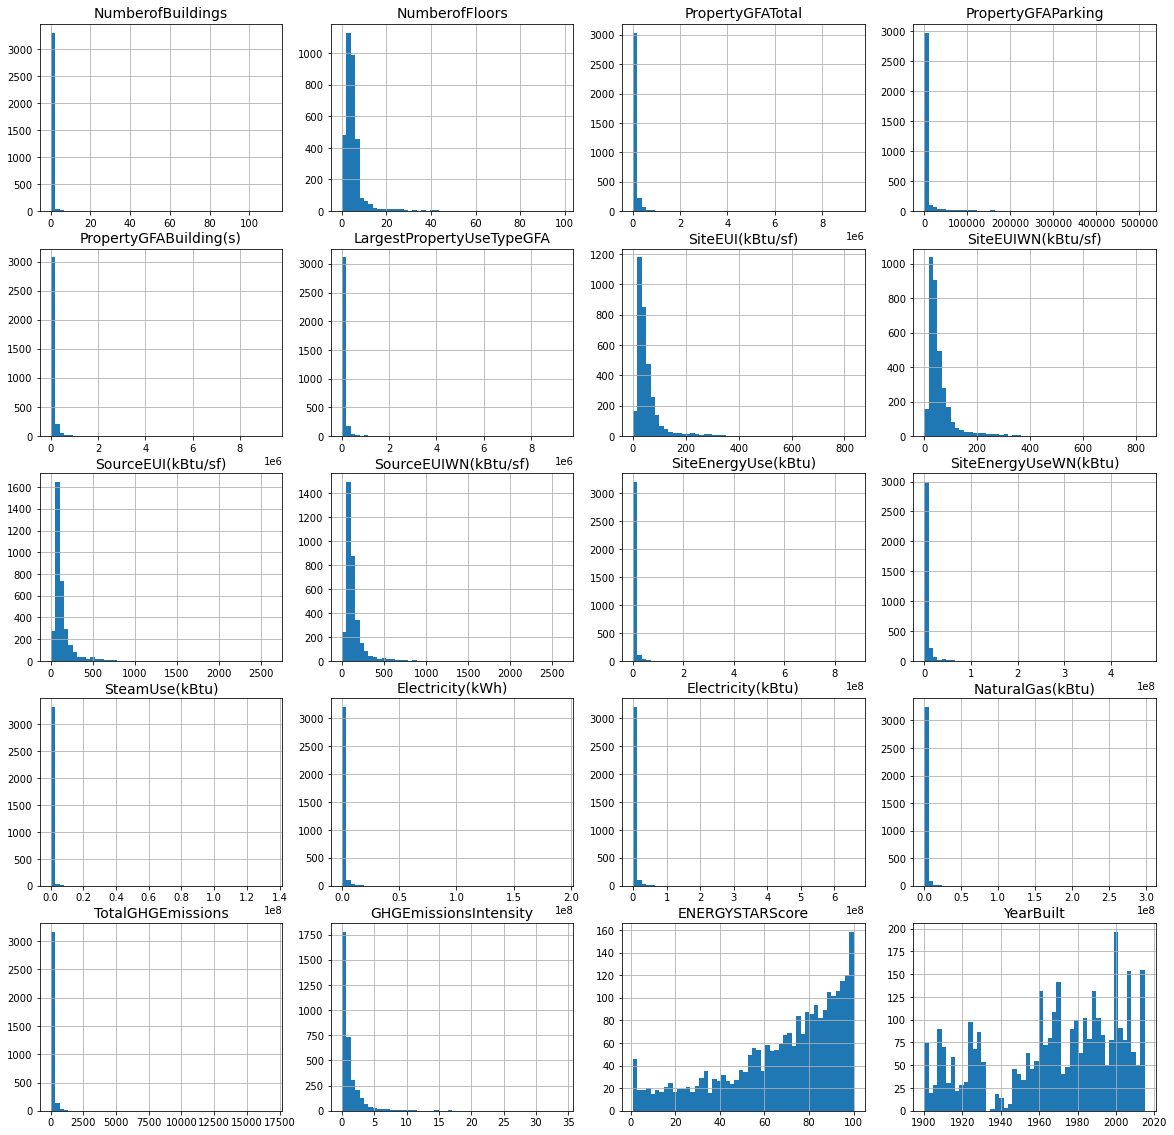

In [39]:
fig = plt.figure(figsize=(20, 20))

for i in range(len(distrib_columns)):
    fig.add_subplot(5,4,i+1)
    ax = data_2016[distrib_columns[i]].hist(bins=50, edgecolor='none')
    ax.set_title(distrib_columns[i], fontsize=14)
    
plt.show()

Distributions of data for 2015 and 2016 years are similar: we can combine them without being too much disturbed about introducing changes in the data distributions.

What may be useful for a linear regression? 
- be aware: some variables have data type float or int, but they are categorical : so, don't use their values as numbers, get dummies of them (or intercept+ -1, effect encoding)
- check whether some categories are subcategories of other, by using a contingency table
- check whether categorical type and numeric GFA are correlated (columns 16-17, 18-19, 20-21) with ANOVA
- PCA with numeric values

2016 unpaired: {'Address',
 'City',
 'Comments',
 'GHGEmissionsIntensity',
 'Latitude',
 'Longitude',
 'State',
 'TotalGHGEmissions',
 'ZipCode'}

2015 unpaired: {'2010 Census Tracts',
 'City Council Districts',
 'Comment',
 'GHGEmissions(MetricTonsCO2e)',
 'GHGEmissionsIntensity(kgCO2e/ft2)',
 'Location',
 'OtherFuelUse(kBtu)',
 'SPD Beats',
 'Seattle Police Department Micro Community Policing Plan Areas',
 'Zip Codes'}

# Combine tables 2015 and 2016

In [40]:
data_2015.OSEBuildingID.duplicated().sum()

0

In [41]:
data_2016.OSEBuildingID.duplicated().sum()

0

## Feature engineering: age

In [42]:
data_2015['Age'] = 2015 - data_2015['YearBuilt']

In [43]:
data_2016['Age'] = 2016 - data_2016['YearBuilt']

## Rename columns

'GHGEmissionsIntensity' is 'GHGEmissionsIntensity(kgCO2e/ft2)' in 2015; 
'TotalGHGEmissions' is 'GHGEmissions(MetricTonsCO2e)' in 2015; 

In [44]:
data_2015 = data_2015.rename(columns={'GHGEmissions(MetricTonsCO2e)':'TotalGHGEmissions',
                                     'GHGEmissionsIntensity(kgCO2e/ft2)':'GHGEmissionsIntensity',
                                     'PropertyGFABuilding(s)':'PropertyGFABuildings',
                                     'SiteEnergyUse(kBtu)':'SiteEnergyUse',
                                     'SiteEUI(kBtu/sf)':'SiteEUI'})

In [45]:
data_2016 = data_2016.rename(columns={'PropertyGFABuilding(s)':'PropertyGFABuildings',
                                     'SiteEnergyUse(kBtu)':'SiteEnergyUse',
                                     'SiteEUI(kBtu/sf)':'SiteEUI'})

"Location" in 2015 table is equal to latitude, longitude, {address, city, state, zip}, where {address} is un-uniformed code of house number, street and district code.

In [46]:
data_2015['Location'] = data_2015['Location'].apply(eval)

In [47]:
data_2015['Latitude'] = data_2015['Location'].apply(lambda x: x['latitude'])
data_2015['Longitude'] = data_2015['Location'].apply(lambda x: x['longitude'])

data_2015['Latitude'] = data_2015['Latitude'].apply(float)
data_2015['Longitude'] = data_2015['Longitude'].apply(float)

## Concatenation

In [48]:
full_data = pd.concat([data_2015, data_2016], ignore_index=True, sort=False)

In [49]:
keep_columns = ['SiteEnergyUse', 'TotalGHGEmissions',
                'SiteEUI', 'GHGEmissionsIntensity',
                'OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 
                'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
                'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 
                'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 
                'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',         
                'Age', 'NumberofBuildings', 'NumberofFloors', 
                'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuildings', 
                'ENERGYSTARScore',
                'ComplianceStatus', 'Outlier']

In [50]:
full_data = full_data[keep_columns]

## City map before building selection

<AxesSubplot:xlabel='Longitude', ylabel='Latitude'>

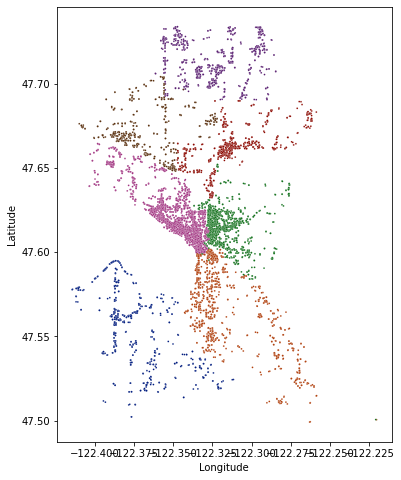

In [51]:
plt.figure(figsize=(6, 8))
sns.scatterplot(x=full_data['Longitude'], y=full_data['Latitude'], s=3, 
                hue=full_data['CouncilDistrictCode'], palette='dark', legend=None)

# Fill missing values

In [52]:
# full_data.info()

In [53]:
full_data.loc[:, 'LargestPropertyUseType'] = full_data.LargestPropertyUseType.fillna(full_data.PrimaryPropertyType)

In [54]:
full_data.loc[:, 'LargestPropertyUseTypeGFA'] = full_data.LargestPropertyUseTypeGFA.fillna(full_data.PropertyGFABuildings)

In [55]:
full_data.loc[:, 'SecondLargestPropertyUseType'] = full_data.SecondLargestPropertyUseType.fillna('no use')

In [56]:
full_data.loc[:, 'SecondLargestPropertyUseTypeGFA'] = full_data.SecondLargestPropertyUseTypeGFA.fillna(0)

In [57]:
full_data.loc[:, 'ThirdLargestPropertyUseType'] = full_data.ThirdLargestPropertyUseType.fillna('no use')

In [58]:
full_data.loc[:, 'ThirdLargestPropertyUseTypeGFA'] = full_data.ThirdLargestPropertyUseTypeGFA.fillna(0)

In [59]:
full_data['NumberofFloors'] = full_data.NumberofFloors.fillna(1)

In [60]:
full_data['Outlier'] = full_data.Outlier.fillna('ok')

# Text processing

In [61]:
to_process = ['BuildingType', 'PrimaryPropertyType', 'Neighborhood', 'LargestPropertyUseType',
              'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'ComplianceStatus', 'Outlier']

In [62]:
for label in to_process:
    full_data.loc[:, label] = full_data[label].apply(str.lower)

In [63]:
# import re
full_data['PrimaryPropertyType'] = [re.compile(r'[\n\r\t]').sub("", item) for index, 
                                    item in full_data.PrimaryPropertyType.iteritems()]

full_data['PrimaryPropertyType'] = [re.compile(r' / ').sub("/", item) for index, 
                                    item in full_data.PrimaryPropertyType.iteritems()]

# Lines selection

## Keep only lines with target values known

In [64]:
full_data = full_data.dropna(subset=['SiteEnergyUse', 'TotalGHGEmissions'])

## "...bâtiments non destinés à l’habitation"

In [65]:
full_data['BuildingType'].value_counts()

nonresidential          2918
multifamily lr (1-4)    2037
multifamily mr (5-9)    1134
multifamily hr (10+)     217
sps-district k-12        191
nonresidential cos       153
campus                    46
nonresidential wa          1
Name: BuildingType, dtype: int64

In [66]:
full_data = full_data[~full_data['BuildingType'].str.contains('family')]

In [67]:
full_data['PrimaryPropertyType'].unique()

array(['hotel', 'other', 'mixed use property', 'k-12 school',
       'college/university', 'small- and mid-sized office',
       'self-storage facility', 'distribution center', 'large office',
       'retail store', 'senior care community', 'medical office',
       'hospital', 'residence hall/dormitory',
       'non-refrigerated warehouse', 'sps-district k-12',
       'worship facility', 'supermarket/grocery store', 'laboratory',
       'refrigerated warehouse', 'restaurant', 'low-rise multifamily',
       'university', 'warehouse', 'residence hall', 'office'],
      dtype=object)

In [68]:
full_data = full_data[~full_data['PrimaryPropertyType'].str.contains('family')]

Some categories can't be defined for sure, if they are "destinés à l'habitation" or not: hotel - can we say people live in the hotel, or they just sleep and eat? university: do some students live in the campus and does it make th whole campus 'destiné à l'habitation'? Senior carre community - do seniors live there, or do they come for daily activities only?
Residence hall/dormitory - do people only sleep there, or do they live there?

The buildings that surely are intended for housing, are "multifamily" buildings. So it's already a good approximation to delete buildings containing "family".

There are buildings that have "family"-containing BuildingType, but not PrimaryPropertyType and LargestPropertyUseType. Or inverse. So, I will delete all the three.

## Select compliant buildings

In [69]:
full_data.ComplianceStatus.unique()

array(['compliant', 'error - correct default data', 'missing data',
       'non-compliant'], dtype=object)

In [70]:
# full_data[full_data.ComplianceStatus == 'missing data']  #.shape

"Missing Data" has to be removed: all the energy consumption values are = 0 (but CO2 emissions are given).
All these buildings are schools.
Their energy sources are given: electricity, for some of them also natural gas.
I could calculate the SiteEnergyUse for them with simple Linear regression, coming from electricity, natural gas and steam use (that is equal to 0 for all the 12 objects). But for now I will drop all these 12 schools.

In [71]:
# full_data[full_data.ComplianceStatus == 'error - correct default data'] #.shape

"Error" has to be removed, in case it contains indeed an error, even though I don't see it

"Non-compliant" means that the house is impossible or inconvenient to live in or to be used for its purpose.

In [72]:
full_data = full_data[(full_data.ComplianceStatus == 'compliant')]
#                      | (full_data.ComplianceStatus == 'Non-Compliant')]

## Edit or delete weird values, that are likely to be false

In [73]:
full_data.describe()

,SiteEnergyUse,TotalGHGEmissions,SiteEUI,GHGEmissionsIntensity,OSEBuildingID,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,CouncilDistrictCode,Latitude,Longitude,Age,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuildings,ENERGYSTARScore
count,3.187000e+03,3187.000000,3187.000000,3187.00000,3187.000000,3.187000e+03,3187.000000,3187.000000,3187.000000,3187.000000,3187.000000,3187.000000,3187.000000,3187.000000,3.187000e+03,3187.000000,3.187000e+03,2113.000000
mean,8.267060e+06,181.135497,73.037057,1.50535,15999.902102,9.616161e+04,18619.864856,3000.030247,4.396297,47.616180,-122.333347,54.056166,1.120803,4.201443,1.169794e+05,13811.854722,1.031675e+05,63.946522
std,2.569489e+07,678.551104,72.945106,2.24943,13408.826727,2.292758e+05,51203.041249,16222.870565,2.196447,0.047479,0.023878,32.801362,2.263170,6.677784,2.548235e+05,44396.129821,2.373862e+05,28.701895
min,0.000000e+00,-0.800000,0.000000,-0.02000,1.000000,5.656000e+03,0.000000,0.000000,1.000000,47.499331,-122.411820,1.000000,0.000000,0.000000,1.128500e+04,-2.000000,-5.055000e+04,1.000000
25%,1.232184e+06,19.910000,33.750000,0.27000,587.000000,2.548000e+04,0.000000,0.000000,2.000000,47.586911,-122.343280,27.000000,1.000000,1.000000,2.923600e+04,0.000000,2.830000e+04,45.000000
50%,2.602214e+06,49.280000,52.700001,0.78000,21129.000000,4.284400e+04,0.000000,0.000000,4.000000,47.612400,-122.333160,50.000000,1.000000,2.000000,4.888200e+04,0.000000,4.680000e+04,71.000000
75%,7.075558e+06,140.960000,83.599998,1.80000,24561.500000,9.140650e+04,12890.000000,0.000000,7.000000,47.648944,-122.322414,86.000000,1.000000,4.000000,1.060000e+05,0.000000,9.471300e+04,88.000000
max,8.739237e+08,16870.980000,834.400024,34.09000,50226.000000,9.320156e+06,686750.000000,459748.000000,7.000000,47.733870,-122.258795,116.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,100.000000


- min(SiteEnergyUse) = 0
- min(totalGHGEmissions) < 0
- min(GHGEmissionsIntensity) < 0
- min(NumberofBuildings) = 0
- min(NumberofFloors) = 0
- min(PropertyGFAParking) < 0
- min(PropertyGFABuildings) < 0

In [74]:
full_data = full_data[full_data['SiteEnergyUse'] > 0]

In [75]:
full_data[full_data['TotalGHGEmissions'] < 0]
# full_data[full_data['TotalGHGEmissions'] < 1]

,SiteEnergyUse,TotalGHGEmissions,SiteEUI,GHGEmissionsIntensity,OSEBuildingID,BuildingType,PrimaryPropertyType,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,CouncilDistrictCode,Neighborhood,Latitude,Longitude,Age,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuildings,ENERGYSTARScore,ComplianceStatus,Outlier
6546,342726.0938,-0.8,7.1,-0.02,49784,nonresidential,small- and mid-sized office,office,48159.0,no use,0.0,no use,0.0,3,central,47.61432,-122.31257,3,1.0,6.0,52000,0,52000,100.0,compliant,ok


This building seems to be not a mistake, but a rare value.

Entries with 0 floors have some buildings (1), their territory isn't 0, so I would like to fill these cells with mode value, 1.

In [76]:
full_data.loc[full_data['NumberofFloors'] == 0, 'NumberofFloors'] = 1

In [77]:
full_data.loc[full_data['NumberofBuildings'] == 0, 'NumberofBuildings'] = 1

In [78]:
full_data.loc[full_data['PropertyGFAParking'] < 0, :]

,SiteEnergyUse,TotalGHGEmissions,SiteEUI,GHGEmissionsIntensity,OSEBuildingID,BuildingType,PrimaryPropertyType,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,CouncilDistrictCode,Neighborhood,Latitude,Longitude,Age,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuildings,ENERGYSTARScore,ComplianceStatus,Outlier
3136,3670298.0,25.59,53.6,0.14,29551,nonresidential,small- and mid-sized office,office,61665.0,bank branch,6787.0,no use,0.0,2,downtown,47.597252,-122.327747,15,1.0,11.0,68452,-2,68454,81.0,compliant,ok


One building has GFA buildings bigger than Total GFA.
I will adjust their Total GFA to Buildings GFA and set the Parking GFA at 0.

In [79]:
full_data.loc[full_data['PropertyGFAParking'] < 0, 
              'PropertyGFATotal'] = full_data.loc[full_data['PropertyGFAParking'] < 0, 'PropertyGFABuildings']

In [80]:
full_data.loc[full_data['PropertyGFAParking'] < 0, 'PropertyGFAParking'] = 0

In [81]:
full_data.loc[full_data['PropertyGFABuildings'] < 0, :]

,SiteEnergyUse,TotalGHGEmissions,SiteEUI,GHGEmissionsIntensity,OSEBuildingID,BuildingType,PrimaryPropertyType,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,CouncilDistrictCode,Neighborhood,Latitude,Longitude,Age,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuildings,ENERGYSTARScore,ComplianceStatus,Outlier
3139,3455247.0,24.09,64.0,0.17,29788,nonresidential,small- and mid-sized office,office,54015.0,no use,0.0,no use,0.0,7,magnolia / queen anne,47.624968,-122.359705,33,1.0,5.0,54015,97325,-43310,65.0,compliant,ok
3322,1389553.0,9.69,35.6,0.11,50002,nonresidential,other,parking,83600.0,automobile dealership,39000.0,no use,0.0,4,northeast,47.664111,-122.316639,1,1.0,3.0,33648,84198,-50550,NaN,compliant,ok


There are two entries: one of them is a parking, and there I have an idea how to set it to correct values:
set the Total GFA equal to Parking GFA, set the Buildings GFA = 0.

But in fact some other informations are confusing: NumberofBuildings is 1, not 0. Well, this could be an automatic filling made before by dataset provider.
But the number of floors is 3, not 0. This doesn't look much like automatic filling. Except that it could be filling by median, but a professional wouldn't fill the NaNs in exponential distribution with the median, he/she would fill it with mode. So, this entry is to be deleted.

But the second entry is a Small- and Mid-sized office - and here I don't know which values (if any) are true, so it's easier to drop this entry.

In [82]:
full_data = full_data[full_data['PropertyGFABuildings'] >= 0]

## Outliers

I checked what the "Outlier" columns could mean in this database, with the following code, exploring the following columns on "x" axis:
- GHGEmissions(MetricTonsCO2e) (target),
- SiteEnergyUseWN(kBtu) (target), 
- SiteEUI(kBtu/sf), PropertyGFABuilding(s) (their product gives SiteEnergyUse not WN)
- ENERGYSTARScore.

Red and blue dots are separated for: 
SiteEUI(kBtu/sf) and all other EUI (WN and Source),
ENERGYSTARScore (the opposite way to EUI),
slightly separated but overlapping each other blue and red points for:
GHGEmissionsIntensity(kgCO2e/ft2).

It seems that "Outlier" means "outlier of calculation of EnergyStar Score regarding to the given energy indicators", because it's the only pair of variables where High outliers and Low Outliers stand in opposite corners of a data cloud. But they don't look like outliers: they are on the background of grey dots, which were labeled as Not Outlier.

I suppose the Outliers were labeled to improve the performance of EnergyStar Score.
As I don't know in advance, whether a new entry will be an outlier or not, it's not a good practice to remove Outlier from a dataset.
We can label an entry as an outlier only when we already know its SiteEUI and know its EnergyStar Score, and say it's not within the trend.
But, if we choose other criteria for our research, not the EnergyStar Score, in a new metric these entries will not necessarily be outliers.

In [83]:
palette_get_outliers = [(0.9, 0.9, 0.8), (0.01, 0.01, 0.99), (0.99, 0.01, 0.01)]

In [84]:
for_scatter = full_data.sort_values(by='Outlier', ascending=False)

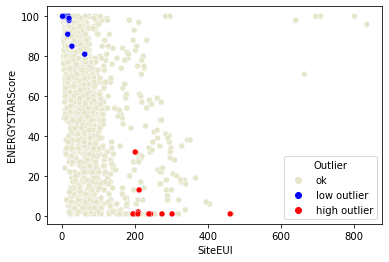

In [85]:
sns.scatterplot (x=for_scatter['SiteEUI'], 
                 y=for_scatter['ENERGYSTARScore'], 
                 hue=for_scatter['Outlier'],
                 legend='full',
                 palette=palette_get_outliers)
plt.show()

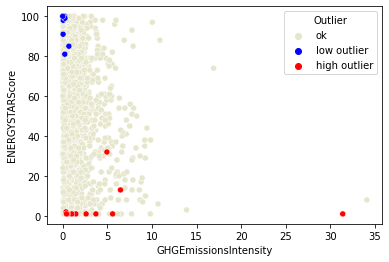

In [86]:
sns.scatterplot (x=for_scatter['GHGEmissionsIntensity'], 
                 y=for_scatter['ENERGYSTARScore'], 
                 hue=for_scatter['Outlier'],
                 legend='full',
                 palette=palette_get_outliers)
plt.show()

I will make a data with cropped outlier values.
There are two approaches:
- crop the entries marked "Outlier" in the dataset;
- crop the entries with extreme values (even if we can't proove that they are false) manually.

The first approach has two drawbacks:
I don't know what the provider means by "outlier", dataset description says just "marks whether an entry is an outlier".
The simple investigation I did, shows that it's likely to be the outliers on EnergyStarScore, which are in poor fit with EnergyUseIntensity.
If I remove outliers by this principle, I will make EnergyStarScore better fit than it is at the moment.

So, I will try second approach.

### Transform numeric columns to log

In [87]:
for_log = ['SiteEnergyUse', 'TotalGHGEmissions', 'SiteEUI',
       'GHGEmissionsIntensity', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuildings']

In [88]:
test = pd.DataFrame()

for item in for_log:
    test[item] = np.log1p(full_data[item])

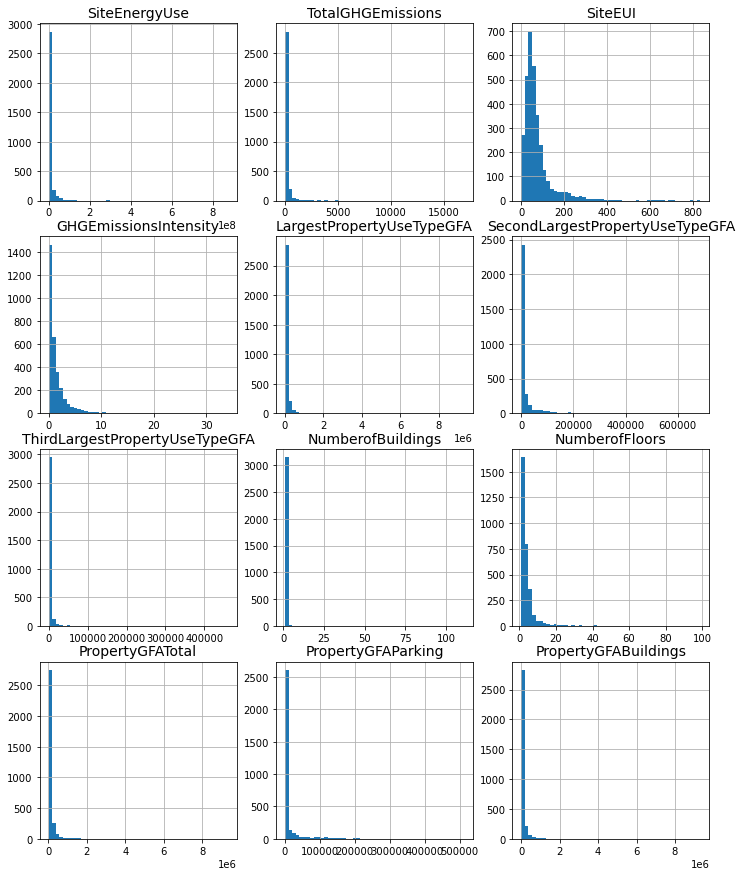

In [89]:
fig = plt.figure(figsize=(12, 15))

for i in range(len(for_log)):
    fig.add_subplot(4,3,i+1)
    ax = full_data[for_log[i]].hist(bins=50, edgecolor='none')
    ax.set_title(for_log[i], fontsize=14)
    
plt.show()

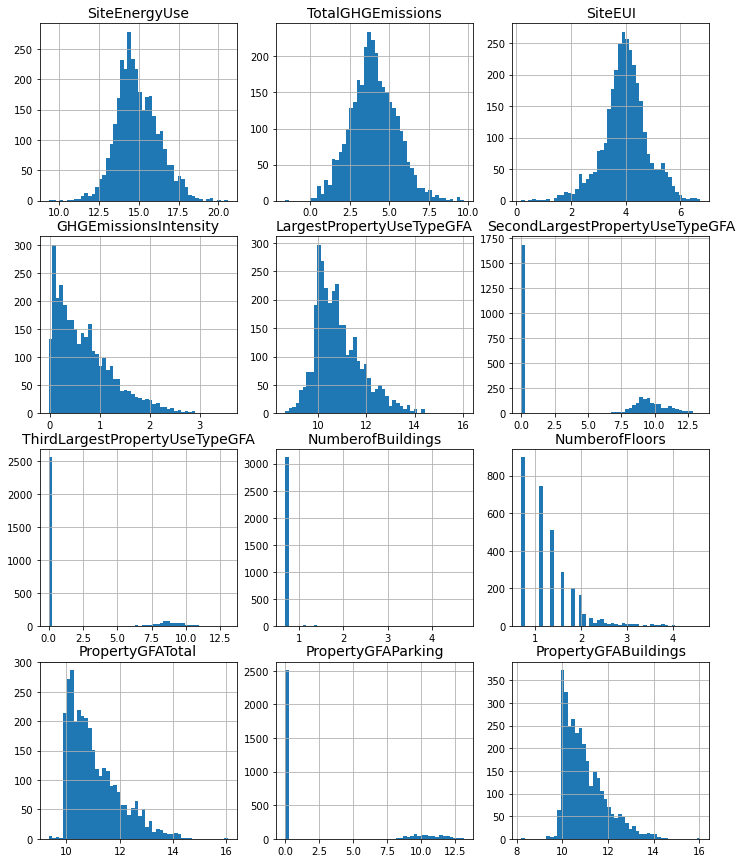

In [90]:
fig = plt.figure(figsize=(12, 15))

for i in range(len(for_log)):
    fig.add_subplot(4,3,i+1)
    ax = test[for_log[i]].hist(bins=50, edgecolor='none')
    ax.set_title(for_log[i], fontsize=14)
    
plt.show()

In [91]:
full_data.insert(1, 'LogSiteEnergyUse', np.log(1 + full_data['SiteEnergyUse']))
full_data.insert(3, 'LogGHGEmissions', np.log(1 + full_data['TotalGHGEmissions']))

#### Test whether GHGEmissions distribution is normal (doesn't look like) and it's logarithm (looks like yes but have to check)

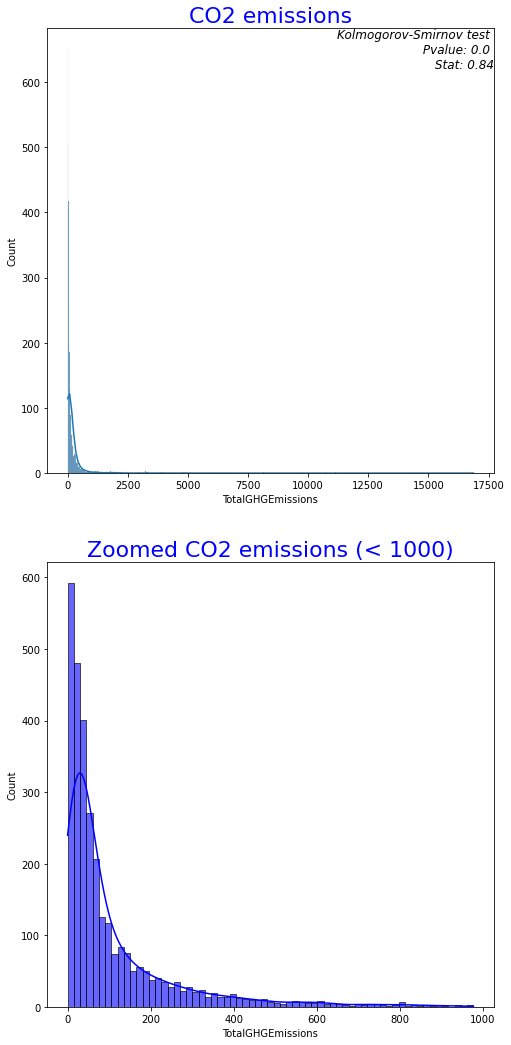

In [92]:
fig, axes = plt.subplots(nrows=2, ncols=1, sharex=False, sharey=False, figsize=(8,18))
left, width = 0, 1
bottom, height = 0, 1
right = left + width
top = bottom + height

sns.histplot(data=full_data, x='TotalGHGEmissions', kde=True, ax=axes[0], alpha=0.6)
axes[0].set_title('CO2 emissions', color='#0000ff', fontsize=22)

#Kolmogorov-Smirnov test
kstest = stats.kstest(full_data['TotalGHGEmissions'].notnull(),'norm')
axes[0].text(right, top, 'Kolmogorov-Smirnov test \n Pvalue: {:.2} \n Stat: {:.2}'.format(kstest.pvalue, kstest.statistic),
            horizontalalignment='right',
            verticalalignment='top',
            style='italic', transform=axes[0].transAxes, fontsize = 12,
#             bbox={'facecolor':'#00afe6', 'alpha':0.5, 'pad':0}
            )

sns.histplot(data=full_data[(full_data['TotalGHGEmissions']< 1000)], 
             x='TotalGHGEmissions', kde=True, ax=axes[1], color='blue', alpha=0.6)
axes[1].set_title('Zoomed CO2 emissions (< 1000)', color='blue', fontsize=22)

# plt.suptitle('CO2 emissions distributions: normal distribution or not', fontsize=22)
plt.show()

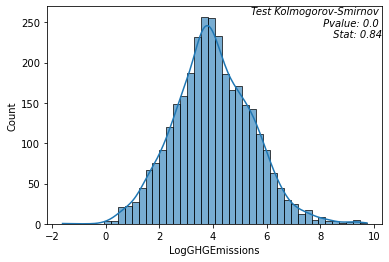

k-test value 0.0
k-test statiscitic 0.8413447460685429


In [93]:
ax = sns.histplot(data=full_data, x="LogGHGEmissions", kde=True, alpha=0.6)
ax.text(1, 1, 'Test Kolmogorov-Smirnov \n Pvalue: {:.2} \n Stat: {:.2}'.format(kstest.pvalue, kstest.statistic),
            horizontalalignment='right',
            verticalalignment='top',
            style='italic', transform=ax.transAxes, fontsize = 10)


# Kolmogorov-Smirnov test
kstest = stats.kstest(full_data['LogGHGEmissions'].notnull(),'norm')

plt.show()
print('k-test value', kstest.pvalue)
print('k-test statiscitic', kstest.statistic)

On the image it looks like normal distribution, maybe with both tails a bit too long, but Kolmogorov-Smirnov test shows that it's not normal: null hypothesis is yes, normal, alternative hypothesis is no, not normal.
If p-value is higher than 0.05, alternative hypothesis is true,
if p-value is lower than 0.05, null hypothesis is true.

But what measures k-test statistics?

I will make another test, a quantile-quantile plot.

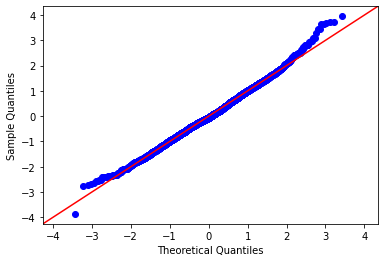

In [94]:
mimin = full_data['LogGHGEmissions'].mean()
styd = full_data['LogGHGEmissions'].std()
testqq = (full_data['LogGHGEmissions'] - mimin) / styd

# import statsmodels.api as sm
# from scipy.stats import norm
# import pylab

sm.qqplot(testqq.values, line='45')
pylab.show()

The QQ-plot shows that the distribution is indeed normal, except the tails (that I called "too long"). The tails are curved up in a similar way to an exponential distribution. The qqplot of an exponential distribution looks like a half-circle.

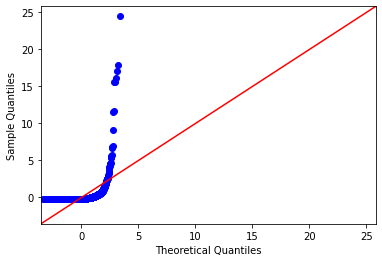

In [95]:
mimin = full_data['TotalGHGEmissions'].mean()
styd = full_data['TotalGHGEmissions'].std()
testqq = (full_data['TotalGHGEmissions'] - mimin) / styd

sm.qqplot(testqq.values, line='45')
pylab.show()

In [96]:
energy_q3 = full_data['LogSiteEnergyUse'].quantile(0.75)
energy_q1 = full_data['LogSiteEnergyUse'].quantile(0.25)
energy_iqr = energy_q3 - energy_q1
uplim_energy = energy_q3 + 1.5 * energy_iqr
lowlim_energy = energy_q1 - 1.5 * energy_iqr

In [97]:
gas_q3 = full_data['LogGHGEmissions'].quantile(0.75)
gas_q1 = full_data['LogGHGEmissions'].quantile(0.25)
gas_iqr = gas_q3 - gas_q1
uplim_gas = gas_q3 + 1.5 * gas_iqr
lowlim_gas = gas_q1 - 1.5 * gas_iqr

In [98]:
print(full_data.shape)
full_data = full_data[(full_data['LogSiteEnergyUse'] > lowlim_energy)
                     & (full_data['LogSiteEnergyUse'] < uplim_energy)]
print(full_data.shape)

(3183, 28)
(3153, 28)


In [99]:
print(full_data.shape)
full_data = full_data[(full_data['LogGHGEmissions'] > lowlim_gas)
                     & (full_data['LogGHGEmissions'] < uplim_gas)]
print(full_data.shape)

(3153, 28)
(3144, 28)


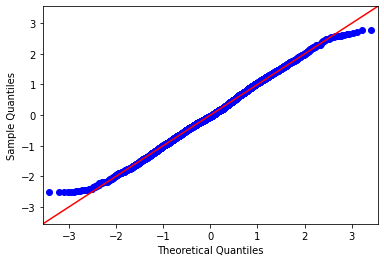

In [100]:
mimin = full_data['LogGHGEmissions'].mean()
styd = full_data['LogGHGEmissions'].std()
testqq = (full_data['LogGHGEmissions'] - mimin) / styd

sm.qqplot(testqq.values, line='45')
pylab.show()

## Duplicated individuals

See if we have rows that describe the same building: 
- by BuildingID; 
- by BuildingID and geographical location only (latitude, longitude) - that doesn't mean the the building has crawled somewhere, but that the measurement was taken badly. 
- by BuildingID and administrative location: that means change in districts and neighbourhood borders between 2015 and 2016.
- by BuildingID and GrossFloorArea / NumberofFloors - that means construction works were undertaken on these buildings.
- by BuildingID and NumberofBuildings: this means change in assignment of buildings to an object, or additional construction or destroyment of a building in a group.

In [101]:
full_data.OSEBuildingID.duplicated().sum()

1477

In [102]:
full_data.duplicated(subset=['OSEBuildingID', 'NumberofBuildings']).sum()

1436

In [103]:
full_data.duplicated(subset=['OSEBuildingID', 'NumberofBuildings', 'NumberofFloors']).sum()

1436

In [104]:
full_data.duplicated(subset=['OSEBuildingID', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal']).sum()

1387

In [105]:
full_data.duplicated(subset=['OSEBuildingID', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFABuildings']).sum()

1357

In [106]:
full_data.duplicated(subset=['OSEBuildingID', 'PropertyGFABuildings']).sum()

1395

The difference in duplicate numbers can be explained with the assumption that for 220 buildings some territory occupied by open-air objects like gardens or parking, was added or removed.

In [107]:
full_data = full_data.drop_duplicates(subset=['OSEBuildingID', 'PropertyGFABuildings'], keep='last')

The optimal approach is the following:
- choose the features and the target for linear regression
- create a new dataframe with only selected columns
- drop duplicates in this new subset dataframe - with all the features duplicated (not necessarily the target).

Well, I can maybe recognize a little bit the ocean bay on the west. I think it makes sense to extract Latitude and Longitude from the address.

## City map after housing deletion and outliers deletion

<AxesSubplot:xlabel='Longitude', ylabel='Latitude'>

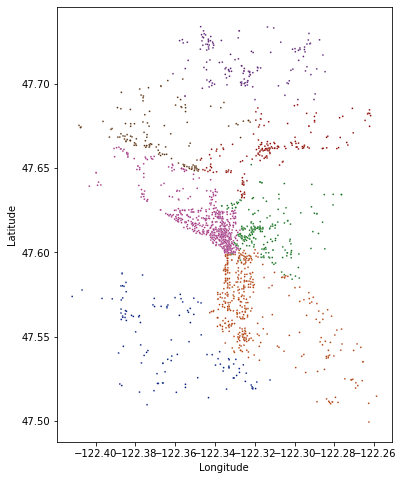

In [108]:
plt.figure(figsize=(6, 8))
sns.scatterplot(x=full_data['Longitude'], y=full_data['Latitude'], s=3, 
                hue=full_data['CouncilDistrictCode'], palette='dark', legend=None)

## Categorical  values grouping

In [109]:
full_data.PrimaryPropertyType.sort_values().unique()

array(['college/university', 'distribution center', 'hospital', 'hotel',
       'k-12 school', 'laboratory', 'large office', 'medical office',
       'mixed use property', 'non-refrigerated warehouse', 'other',
       'refrigerated warehouse', 'residence hall',
       'residence hall/dormitory', 'restaurant', 'retail store',
       'self-storage facility', 'senior care community',
       'small- and mid-sized office', 'sps-district k-12',
       'supermarket/grocery store', 'university', 'warehouse',
       'worship facility'], dtype=object)

In [110]:
full_data['PrimaryPropertyType'] = full_data['PrimaryPropertyType'].str.replace('college/', '')

The following line is correct if unspecified warehouse means non-refrigerated warehouse, and not, say, mixture of both.

In [111]:
full_data['PrimaryPropertyType'] = full_data['PrimaryPropertyType'].str.replace('non-refrigerated ', '')

In [112]:
full_data['PrimaryPropertyType'] = full_data['PrimaryPropertyType'].str.replace('/dormitory', '')

In [113]:
full_data['PrimaryPropertyType'] = full_data['PrimaryPropertyType'].str.replace('sps-district k-12', 'k-12 school')

In [114]:
full_data.LargestPropertyUseType.sort_values().unique()

array(['adult education', 'automobile dealership', 'bank branch',
       'college/university', 'convention center', 'courthouse',
       'data center', 'distribution center', 'financial office',
       'fire station', 'fitness center/health club/gym', 'food service',
       'hospital (general medical & surgical)', 'hotel', 'k-12 school',
       'laboratory', 'library', 'lifestyle center',
       'manufacturing/industrial plant', 'medical office',
       'mixed use property', 'movie theater', 'multifamily housing',
       'museum', 'non-refrigerated warehouse', 'office', 'other',
       'other - education', 'other - entertainment/public assembly',
       'other - lodging/residential', 'other - mall',
       'other - public services', 'other - recreation',
       'other - restaurant/bar', 'other - services', 'other - utility',
       'other/specialty hospital',
       'outpatient rehabilitation/physical therapy', 'parking',
       'performing arts',
       'personal services (health/beau

In [115]:
len(full_data.LargestPropertyUseType.value_counts())

# no way I will use this column as categorical for get dummies! It has 60 distinct values!

60

### Contingency table

Shows the correlation between two categorical variables: if they are correlated, it makes sense to choose only one of them for inclusion in the model.

In [116]:
X = 'PrimaryPropertyType'
Y = 'LargestPropertyUseType'

cont = full_data[[X,Y]].pivot_table(index=X,columns=Y,aggfunc=len,margins=True,margins_name="Total")

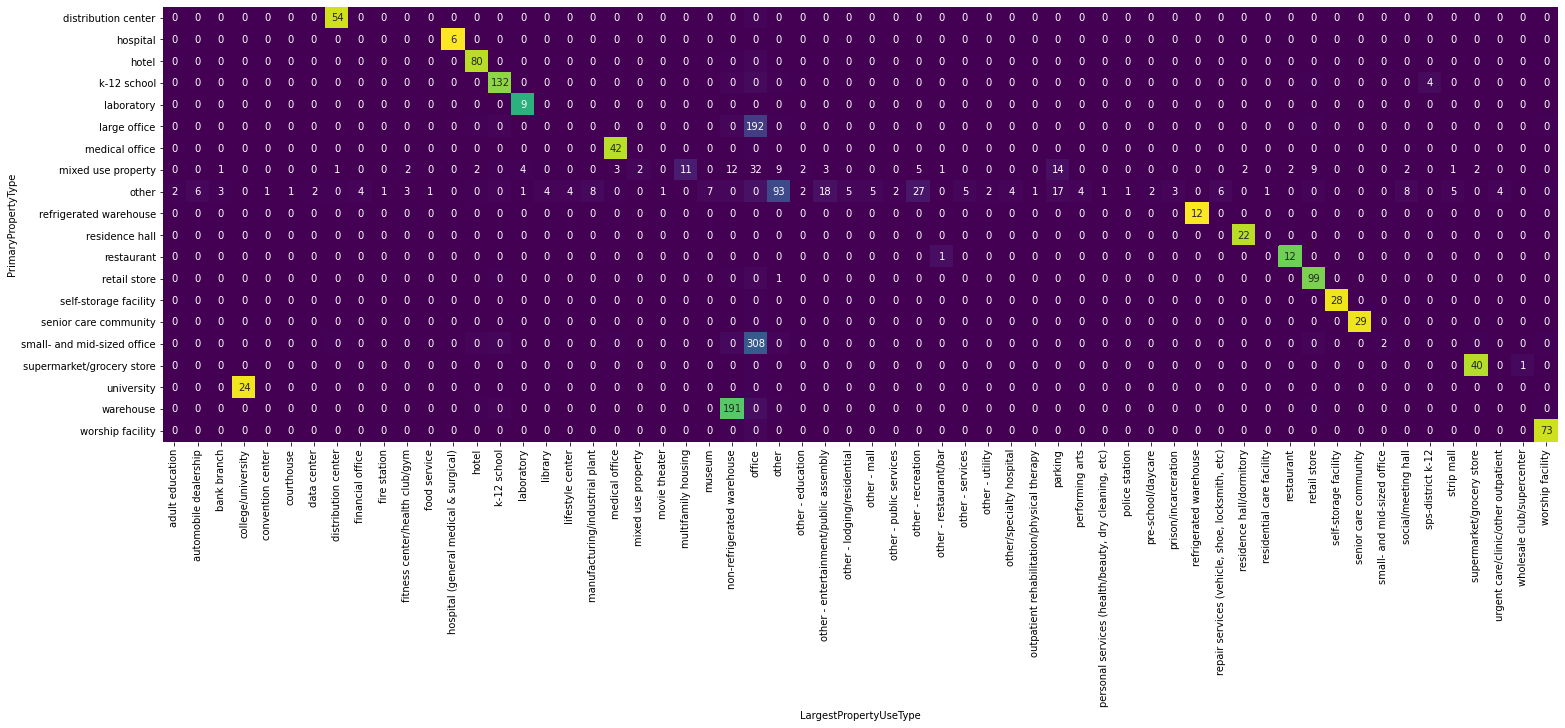

In [117]:
tx = cont.loc[:,["Total"]]
ty = cont.loc[["Total"],:]
n = len(full_data)
indep = tx.dot(ty) / n

c = cont.fillna(0) # Replace null values by 0
measure = (c-indep)**2/indep
xi_n = measure.sum().sum()
table = measure/xi_n

plt.figure(figsize=(25, 8))
sns.heatmap(table.iloc[:-1,:-1],annot=c.iloc[:-1,:-1], fmt='g', 
            cbar=False,
            cmap='viridis'
           )
plt.show()

clearly no need to use both of these variables.

In [118]:
X = 'BuildingType'
Y = 'PrimaryPropertyType'

cont = full_data[[X,Y]].pivot_table(index=X,columns=Y,aggfunc=len,margins=True,margins_name="Total")

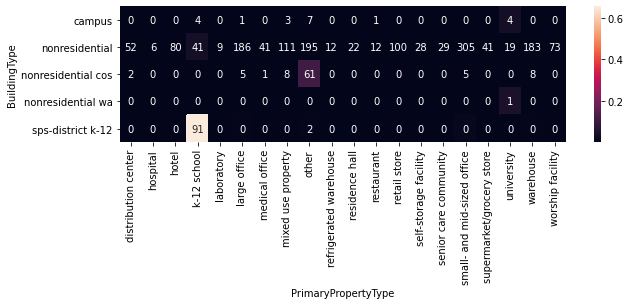

In [119]:
tx = cont.loc[:,["Total"]]
ty = cont.loc[["Total"],:]
n = len(full_data)
indep = tx.dot(ty) / n

c = cont.fillna(0) # Replace null values by 0
measure = (c-indep)**2/indep
xi_n = measure.sum().sum()
table = measure/xi_n

plt.figure(figsize=(10, 2.5))
sns.heatmap(table.iloc[:-1,:-1],annot=c.iloc[:-1,:-1], fmt='g')
plt.show()

These variables seem not super correlated, except k-12 school and sps-district k-12. nevertheless, BuildingType seems less important, as most of it is concentrated in "nonresidential" subgroup.

In [120]:
X = 'Neighborhood'
Y = 'CouncilDistrictCode'

cont = full_data[[X,Y]].pivot_table(index=X,columns=Y,aggfunc=len,margins=True,margins_name="Total")

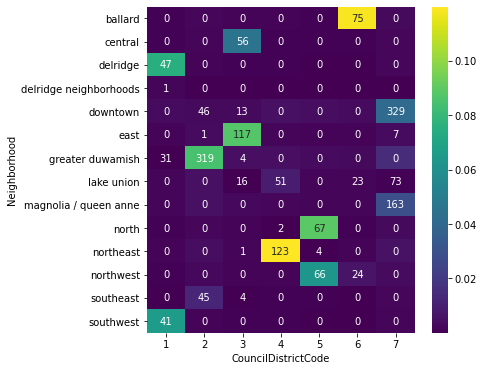

In [121]:
tx = cont.loc[:,["Total"]]
ty = cont.loc[["Total"],:]
n = len(full_data)
indep = tx.dot(ty) / n

c = cont.fillna(0) # On remplace les valeurs nulles par 0
measure = (c-indep)**2/indep
xi_n = measure.sum().sum()
table = measure/xi_n

plt.figure(figsize=(6, 6))
sns.heatmap(table.iloc[:-1,:-1],annot=c.iloc[:-1,:-1], fmt='g', cmap='viridis')
plt.show()

I also don't need both of Neighbourhood and CouncilDistrict - they are highly correlated, so their dummies will be.

### Feature engineering: logarithm of variables with exponential distribution

I did a log transformation on traget columns. Why not make a log transformation on some features? I saw that all the distributions are roughly exponential. But log transform shows that it's not the case.  LargestPropertyUseTypeGFA seems to be somewhat a triangle shape, less far from normal distribution than before. PropertyGFATotal and PropertyGFABuildings are still far from normal: they look like a right triangle (triangle rectangle). PropertyGFAParking is a little bell, I don't see if it's normal or not, with a high minareth next to 0.

I will try to add the abovenamed log-transformed variables to the dataset and see the correlation matrrix

Note that the resulted log-variables still don't have a normal distribution

In [122]:
for_log = ['LargestPropertyUseTypeGFA','PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuildings']

In [123]:
test = pd.DataFrame()

for item in for_log:
    test[item] = np.log1p(full_data[item])

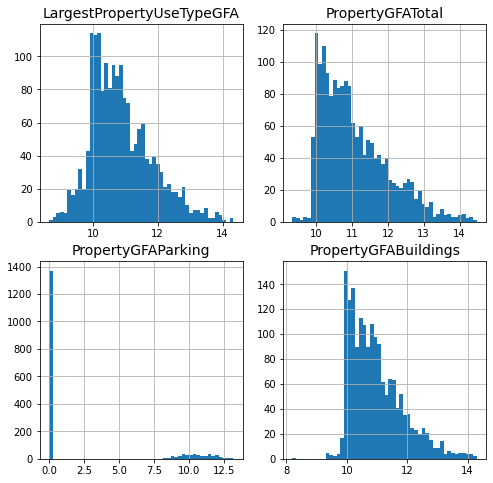

In [124]:
fig = plt.figure(figsize=(8, 8))

for i in range(len(for_log)):
    fig.add_subplot(2,2,i+1)
    ax = test[for_log[i]].hist(bins=50, edgecolor='none')
    ax.set_title(for_log[i], fontsize=14)
    
plt.show()

In [125]:
for item in for_log:
    full_data['Log'+item] = np.log1p(full_data[item])

### Feature engineering: distance from center of Seattle

In [126]:
lat = 47.6062
long = -122.3321
full_data['Distance'] = np.sqrt(((full_data['Latitude'] - lat) * 100) ** 2 + 
                                ((full_data['Longitude'] - long) * 100) ** 2)

### Feature engineering: buildingsGFAproportion, ScoreTimesGFA

In [127]:
full_data['BuildingsGFAProportion'] = full_data.PropertyGFABuildings / full_data.PropertyGFATotal

In [128]:
full_data['ScoreTimesGFA'] = full_data.ENERGYSTARScore * full_data.PropertyGFATotal

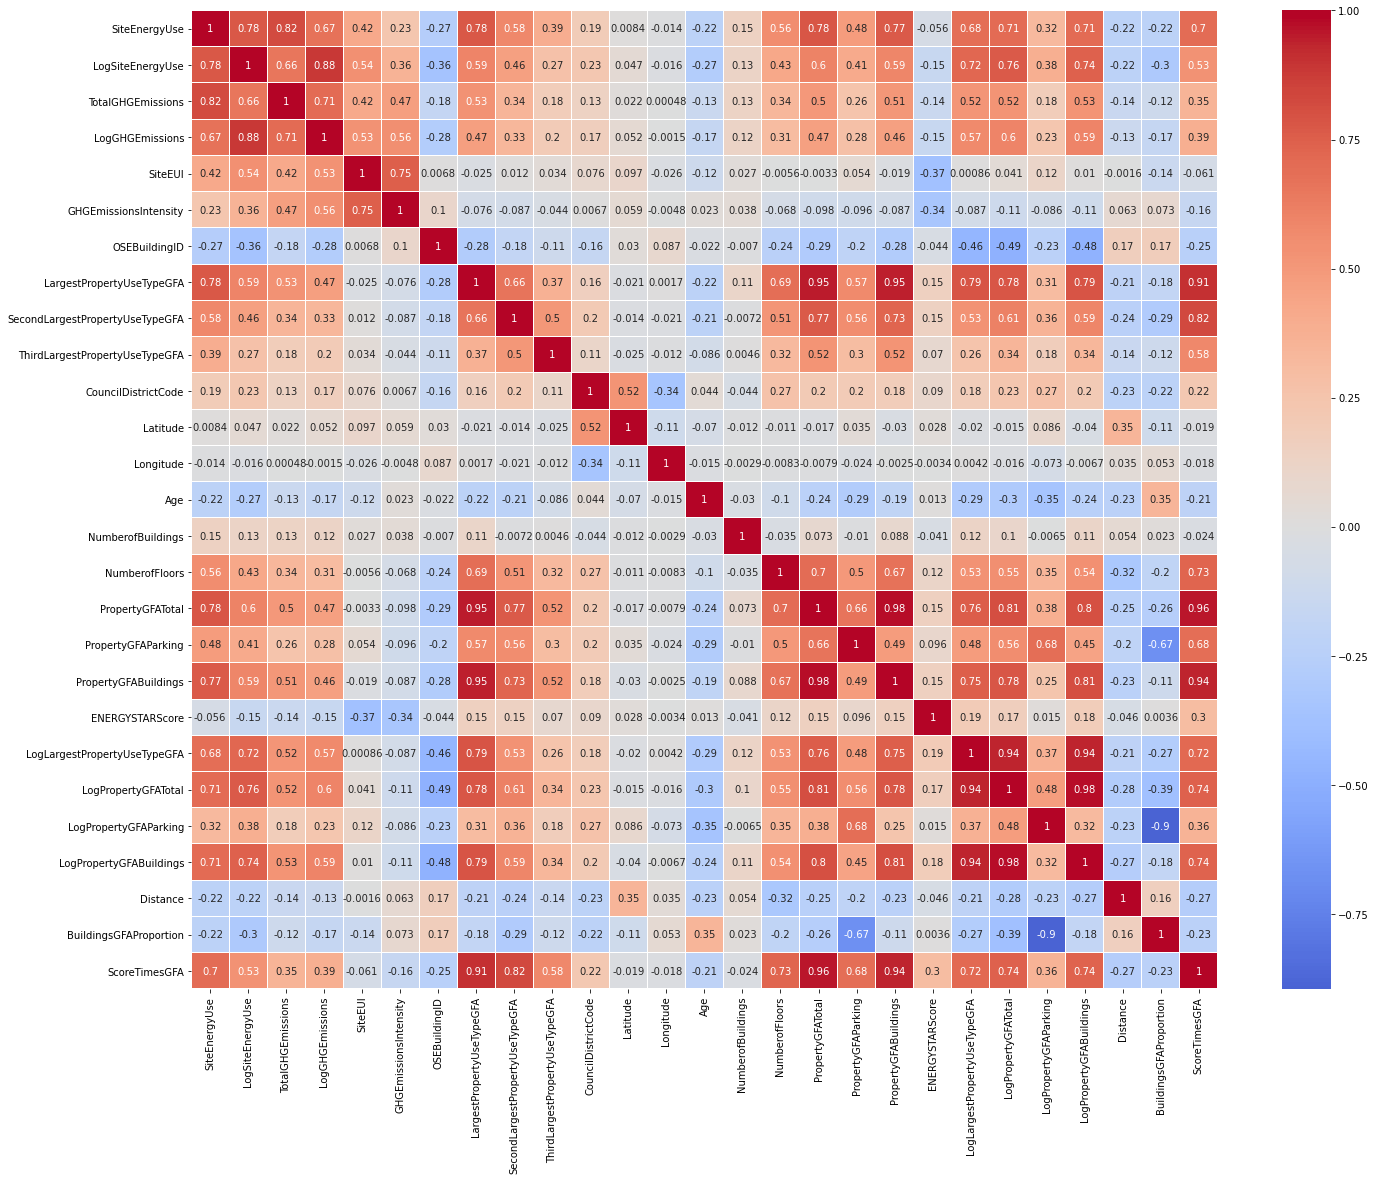

In [129]:
corr_matr = full_data.corr()
fig = plt.figure(figsize=(23,18))
sns.heatmap(corr_matr, square=False, linewidths=0.01, center=0, annot=True, cmap='coolwarm') # mask=mask, 
# center=0 is a center of the colorscale: to which value the center of the colorscale is assigned
# coolwarm_r for reverse
plt.xticks(rotation=90)
# plt.title("Correlations between variables")
plt.show()

BuildingID is supposed to be not correlated linearly with the targets. Nevertheless, it correlates with them significantly more than ENERGYSTARScore.

Nevertheless, I see some correlation between ENERGYSTARScore and SiteEUI, and GHGEmissionsIntensity.
So, maybe somewhat an efficient predictor would be not ENERGYSTARSCORE, but its product with GFABuildings.

I will not include information concerning second and third property use and their GFAs - it would give too many variables, useless for the model, and significantly correlated with other GFAs.

In [130]:
for_predictions = ['SiteEnergyUse', 'LogSiteEnergyUse', 'TotalGHGEmissions', 'LogGHGEmissions', 
                   'PrimaryPropertyType', 'Neighborhood',
                   'OSEBuildingID',
                   'NumberofBuildings', 'NumberofFloors',
                   'PropertyGFAParking', 'PropertyGFABuildings',  # 'PropertyGFATotal'
                   'BuildingsGFAProportion', 'Distance',
                   'ENERGYSTARScore', 'ScoreTimesGFA',
                   'LogLargestPropertyUseTypeGFA', 'LogPropertyGFATotal',
                   'LogPropertyGFAParking', 'LogPropertyGFABuildings'
                  ]

In [131]:
full_data = full_data[for_predictions]

In [132]:
full_data.to_csv(relativepath + 'seattle_energy_predict.csv', index=False)

In [133]:
pd.read_csv(relativepath + 'seattle_energy_predict.csv').shape  #, sep='\t')

(1749, 19)